In [20]:
from datetime import datetime
from doctr.io import DocumentFile
from doctr.models import ocr_predictor
from PIL import Image
import numpy as np
from deepface import DeepFace
import matplotlib.image as mpimg
import cv2
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import re


In [21]:
model = ocr_predictor(pretrained=True)

def extract_text(ocr_model, image_file_path: str):
    """Extrae el texto de una imagen a partir de un modelo OCR"""

    doc = DocumentFile.from_images(image_file_path)
    result = ocr_model(doc)
    return result

def show_ocr_result(result):
    """Muestra una imagen de resultado y el texto extraido"""

    # mostrar resultado
    #result.show()
    lista = []
    # mostrar texto con mas de 50% de confianza
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                words = []
                for word in line.words:
                    if word.confidence > 0.5:
                        words.append(word.value)
                lista.append(' '.join(words))

    return lista

In [22]:
def extraccion_antiguo(words_ante):

    info = {}
    text = '\n'.join(words_ante)

    m = re.search(r'(?:DNI[\s/]?)(\d{8}[A-Z])|\b(\d{8}[A-Z])\b', text)
    if m:
        info['dni'] = m.group(1) or m.group(2)

    m = re.search(r'APEL[^\n]*\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]*?)\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]*?)\n', text)
    if m:
        info['apellido1'] = m.group(1).strip()
        ap2 = m.group(2).strip()
        if 'NOM' not in ap2:
            info['apellido2'] = ap2
    else:
        m = re.search(r'APEL[^\n]*\n([A-ZÁÉÍÓÚÜÑ]+)\s+([A-ZÁÉÍÓÚÜÑ]+)', text)
        if m:
            info['apellido1'] = m.group(1)
            ap2 = m.group(2)
            if 'NOM' not in ap2:
                info['apellido2'] = ap2


    nom_matches = list(re.finditer(r'NOM[^\n]*\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]+)', text))
    if nom_matches:
        partes = nom_matches[-1].group(1).strip().split()
        info['nombre1'] = partes[0]
        if len(partes) > 1:
            info['nombre2'] = partes[1]

    m = re.search(r'FECHA[^\n]*\n(\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if not m:
        m = re.search(r'FECHA[\w/\s]*(\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if m:
        info['f_nacimiento'] = m.group(1)

    m = re.search(r'VALI[^\n]*\n([A-Z0-9]{9})[\s]+(\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if not m:
        m = re.search(r'VALI[\w/\s]*([A-Z0-9]{9})[\s-](\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if m:
        info['num_sop'] = m.group(1)
        info['f_validez'] = m.group(2)

    return info

In [23]:
def extraccion_moderno(words_ante):
 
    info = {}
    text = '\n'.join(words_ante)

    m = re.search(r'(?:DNI[\s/]?)(\d{8}[A-Z])|\b(\d{8}[A-Z])\b', text)
    if m:
        info['dni'] = m.group(1) or m.group(2)

    m = re.search(r'\b([A-Z]{3}\d{6})\b', text)
    if m:
        info['num_sop'] = m.group(1)

    m = re.search(r'APEL[^\n]*\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]*?)\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]*?)\n', text)
    if m:
        info['apellido1'] = m.group(1).strip()
        ap2 = m.group(2).strip()
        if 'NOM' not in ap2:
            info['apellido2'] = ap2
    else:
        m = re.search(r'APEL[^\n]*\n([A-ZÁÉÍÓÚÜÑ]+)\s+([A-ZÁÉÍÓÚÜÑ]+)', text)
        if m:
            info['apellido1'] = m.group(1)
            ap2 = m.group(2)
            if 'NOM' not in ap2:
                info['apellido2'] = ap2

    nom_matches = list(re.finditer(r'NOM[^\n]*\n([A-ZÁÉÍÓÚÜÑ][A-ZÁÉÍÓÚÜÑ ]+)', text))
    if nom_matches:
        partes = nom_matches[-1].group(1).strip().split()
        info['nombre1'] = partes[0]
        if len(partes) > 1:
            info['nombre2'] = partes[1]

    m = re.search(r'\bESP\b[^\n]*\n(\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if not m:
        m = re.search(r'\bESP\b\s+(\d{2}[\s.-]\d{2}[\s.-]\d{4})', text)
    if m:
        info['f_nacimiento'] = m.group(1)

    m = re.search(
        r'VALI[^\n]*\n(\d{2}[\s.-]\d{2}[\s.-]\d{4})[\s\n]+(\d{2}[\s.-]\d{2}[\s.-]\d{4})',
        text
    )
    if not m:
        m = re.search(
            r'VALI[\w/\s]*(\d{2}[\s.-]\d{2}[\s.-]\d{4})[\s]+(\d{2}[\s.-]\d{2}[\s.-]\d{4})',
            text
        )
    if m:
        info['f_emision'] = m.group(1)
        info['f_validez'] = m.group(2)

    return info

In [24]:
def val_digitos(info):
    letra = ['T', 'R', 'W', 'A', 'G', 'M', 'Y', 'F', 'P', 'D', 'X', 'B', 'N', 'J', 'Z', 'S', 'Q', 'V', 'H', 'L', 'C', 'K', 'E']
    dni = info['dni']
    dig = int(dni[:8])
    let = dni[8:]
    aux = dig%23

    if let != letra[aux]:
        print('DNI NO VALIDO, VUELVA A INTENTARLO')
        

In [25]:
def val_fechas(info):
    fecha1_str = info['f_emision']
    fecha1 = datetime.strptime(fecha1_str, "%d %m %Y")
    fecha2_str = info['f_nacimiento']  
    fecha2 = datetime.strptime(fecha2_str, "%d %m %Y")
    fecha3_str = info['f_validez'] 
    fecha3 = datetime.strptime(fecha3_str, "%d %m %Y")

    edad = fecha1.year - fecha2.year
    if (fecha1.month, fecha1.day) < (fecha2.month, fecha2.day):
        edad -= 1
        
    renov = fecha3.year - fecha1.year

    if edad < 5 and renov == 2:
        return
    elif edad < 30 and renov == 5:
        return
    elif edad < 70 and renov == 10:
        return
    else:
        print('DNI NO VALIDO, VUELVA A INTENTARLO')

In [26]:
def extraer_edad(info):
    fecha1 = datetime.now()
    fecha2_str = info['f_nacimiento']  
    fecha2 = datetime.strptime(fecha2_str, "%d %m %Y")

    edad = fecha1.year - fecha2.year
    if (fecha1.month, fecha1.day) < (fecha2.month, fecha2.day):
        edad -= 1

    return edad 

In [27]:
def val_caducidad(info):
    fecha3_str = info['f_validez'] 
    fecha3 = datetime.strptime(fecha3_str, "%d %m %Y")
    fecha4 = datetime.now()

    if fecha3 > fecha4:
        return
    else:
        print('DNI NO VALIDO, VUELVA A INTENTARLO')


In [28]:
def procesar_filas(words_reve, info):


    fila1, fila2, fila3 = words_reve[-3:]


    info_fila1 = [
        fila1[:5],
        fila1[5:14],
        fila1[14:15],
        fila1[15:24],
        fila1[25:]      
    ]

    n = len(fila2)

    info_fila2 = [
        fila2[:6],
        fila2[6:8],
        fila2[8:14],
        fila2[14:15],
        fila2[15:18],
        fila2[18:n-1],
        fila2[n-1:]
    ]

    claves = []
    for clave, valor in info.items():
        claves.append(clave)

    try:
        ap1 = len(info["apellido1"])
        ap2 = len(info["apellido2"])
        n1  = len(info["nombre1"])
        if 'nombre2' in claves:
            n2  = len(info['nombre2'])  
        else: 
            n2 = 0
        
    except KeyError as e:
        raise ValueError(f"Falta la clave en info: {e}")

    n_total = n1 + n2  

    pos = 0

    parte1 = fila3[pos:pos+ap1]
    pos += ap1

    parte2 = fila3[pos:pos+1]
    pos += 1

    parte3 = fila3[pos:pos+ap2]
    pos += ap2

    parte4 = fila3[pos:pos+2]
    pos += 2

    if n2 != 0:

        parte5 = fila3[pos:pos+n1]
        pos += n1
    
        parte6 = fila3[pos:pos+1]
        pos += 1

        parte7 = fila3[pos:]

        info_fila3 = [
            parte1,
            parte2,
            parte3,
            parte4,
            parte5, 
            parte6,
            parte7
        ]

    else:
        parte5 = fila3[pos:pos+n_total]
        pos += n_total

        parte6 = fila3[pos:]

        info_fila3 = [
            parte1,
            parte2,
            parte3,
            parte4,
            parte5, 
            parte6
        ]

    return info_fila1, info_fila2, info_fila3

In [29]:
def formatear_fecha(valor):
        grupos = [valor[i:i+2] for i in range(0, len(valor), 2)]
        return ' '.join(grupos[::-1])
    
    
def limpiar(valor):
    return valor.replace('<', '').strip()


def construir_info_reverso(info_fila1, info_fila2, info_fila3):
    
    f_nac = formatear_fecha(info_fila2[0])
    f_val = formatear_fecha(info_fila2[2])

    info_reverso = {
        'num_sop': limpiar(info_fila1[1]),
        'dni': limpiar(info_fila1[3]),
        'f_nacimiento': f_nac,
        'f_validez': f_val,
        'apellido1': limpiar(info_fila3[0]),
        'apellido2': limpiar(info_fila3[2]),
        'nombre1': limpiar(info_fila3[4]),
    }

    posible_nombre2 = limpiar(info_fila3[6]) if len(info_fila3) > 6 else ""

    if posible_nombre2:
        info_reverso['nombre2'] = posible_nombre2

    return info_reverso

In [30]:
def normalizar_fecha(fecha):
    if not fecha or len(fecha) < 8:
        return fecha
    return fecha[:2] + fecha[2:6] + fecha[8:]


def comparar_info(info, info_reverso, verbose=True):

    resultados = {}

    comparaciones = {
        "dni": ("El dni", lambda a, b: a == b),
        "num_sop": ("El num_sop", lambda a, b: a == b),
        "f_nacimiento": ("La fecha de nacimiento",
                         lambda a, b: normalizar_fecha(a) == b),
        "f_validez": ("La fecha de validez",
                      lambda a, b: normalizar_fecha(a) == b),
        "apellido1": ("El primer apellido", lambda a, b: a == b),
        "apellido2": ("El segundo apellido", lambda a, b: a == b),
        "nombre1": ("El primer nombre", lambda a, b: a == b),
    }

    for clave, (texto, comparador) in comparaciones.items():
        v1 = info.get(clave)
        v2 = info_reverso.get(clave)

        if v1 is None or v2 is None:
            resultados[clave] = None
            if verbose:
                print(f"{texto}: no se pudo comparar (dato faltante)")
            continue

        coincide = comparador(v1, v2)
        resultados[clave] = coincide

        if verbose:
            print(f"{texto} {'coincide' if coincide else 'no coincide'}")

    v1 = info.get("nombre2")
    v2 = info_reverso.get("nombre2")

    if not v1 and not v2:
        resultados["nombre2"] = True
        if verbose:
            print("El segundo nombre coincide (no presente en ambos)")
    elif v1 and v2:
        coincide = v2 in v1
        resultados["nombre2"] = coincide
        if verbose:
            print(f"El segundo nombre {'coincide' if coincide else 'no coincide'}")
    else:
        resultados["nombre2"] = None
        if verbose:
            print("El segundo nombre: no se pudo comparar (solo presente en uno)")

    return resultados

In [43]:
def validar_dni(img1, img2, selfie=None, verificar_edad=False):
    try:
        text = extract_text(model, img1)
        words_ante = show_ocr_result(text)
        
        text = extract_text(model, img2)
        words_reve = show_ocr_result(text)

        reino = False
        for i in range(len(words_ante)):
            if 'REINO' in words_ante[i]:
                reino = True

        if reino:  
            print('DNI MODERNO')
            info = extraccion_moderno(words_ante)
            val_fechas(info)

        else:
            print('DNI ANTIGUO')
            info = extraccion_antiguo(words_ante)
        
        val_digitos(info)
        val_caducidad(info)
                 
        info_fila1, info_fila2, info_fila3 = procesar_filas(words_reve, info)
        info_reverso = construir_info_reverso(info_fila1, info_fila2, info_fila3)

        comparar_info(info, info_reverso)

        if selfie is not None and verificar_edad:
            age = extraer_edad(info)
            predicted_age = DeepFace.analyze(selfie, detector_backend='retinaface', actions=['age'])[0]['age']
            print(f'Edad según el DNI: {age}\nEdad estimada por el modelo: {predicted_age}')
            if abs(age-predicted_age)>10:
                print("POSIBLE INCONSISTENCIA DE EDAD")
            else:
                print("Edad coherente con el DNI")
                
    except KeyError as e:
        raise ValueError (f'LOS CAMPOS NO SE HAN PODIDO VERIFICAR, SUBA OTRA IMAGEN DEL DNI')


In [32]:
def real_time_verification(dni_path, model_name='ArcFace', detector_backend = 'retinaface'):
    """Función para verificar que el rostro del usuario y el que aparece en el DNI coinciden 
    en tiempo real con anti-spoofing incorporado"""

    # Config
    threshold = 0.68
    processing_frame_rate = 50
    
    #  Extraer embedding del rostro del DNI
    dni = DeepFace.extract_faces(dni_path, detector_backend)[0]['face']
    # Muestra la imagen
    plt.imshow(dni)
    plt.axis('off')
    plt.title('Rostro del DNI')
    plt.show()
    
    dni_embedding = DeepFace.represent(
                    dni,
                    model_name,
                    detector_backend='skip',
                )[0]["embedding"]


    #  Webcam setup optimizado
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    frame_count = 0
    last_status = "Scanning..."
    last_distance = None

    while True:
        
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Procesar solo cada N frames para que el vídeo vaya un poco más fluido
        if frame_count % processing_frame_rate == 0:
            try:
                #obtener embedding del rostro dentro de la imagen captada por la cámara
                face_frame = DeepFace.extract_faces(frame, detector_backend)[0]['face'] 
                live_embedding = DeepFace.represent(
                face_frame,
                model_name,
                detector_backend='skip',
                anti_spoofing=True
                )[0]["embedding"]

                distance = cosine(dni_embedding, live_embedding) #función de perdida

                last_distance = distance

                if distance < threshold:
                    last_status = "MATCH"  #Si la diferencia de los rostros es menor al umbral, verificación correcta
                else:
                    last_status = "NO MATCH"

            except Exception:
    
                last_status = "Spoofing Detected!"
                last_distance = None

        # Dibujar mensaje en verde si hay match, si no en rojo
        color = (0, 255, 0) if last_status == "MATCH" else (0, 0, 255)

        text = last_status
        if last_distance is not None:
            text += f" | {last_distance:.3f}"

        cv2.putText(
            frame,
            text,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            color,
            2
        )

        cv2.imshow("Verification", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

In [33]:
def one_shot_verification(dni_path, selfie_path, model_name='ArcFace', detector_backend = 'retinaface'):
    '''
    Identity verification for a single frame. This function has the purpose of demonstrating the functionality
    of the streaming version'''

    print("Escaneando...")
    treshold = 0.68
    dni = DeepFace.extract_faces(dni_path, detector_backend)[0]['face']
    dni_embedding = DeepFace.represent(
                    dni,
                    model_name,
                    detector_backend='skip',
                )[0]["embedding"]
    
    selfie = DeepFace.extract_faces(selfie_path, detector_backend)[0]['face'] 
    selfie_embedding = DeepFace.represent(
                selfie,
                model_name,
                detector_backend='skip',
                anti_spoofing=True
                )[0]["embedding"]
    

    fig, axs = plt.subplots(1,2)
    axs[0].axis('off')
    axs[0].imshow(dni)
    axs[0].set_title("Foto del DNI")
    axs[1].axis('off')
    axs[1].imshow(selfie)
    axs[1].set_title("Selfie del usuario")
    
    distance = cosine(dni_embedding,selfie_embedding)

    if distance < treshold:
        fig.suptitle(f"Verificación exitosa \n Modelo:{model_name} | Detector:{detector_backend} | Distancia:{np.round(distance,2)}",color='green')
    else:
        fig.suptitle(f"Autenticación denegada\n Modelo: {model_name} | Detector: {detector_backend} | Distancia:{np.round(distance,2)}", color="red")
        
    

In [48]:
def pipeline(dni_anverso, dni_reverso, selfie=None, verificar_edad=False, live=False, model_name='ArcFace', detector_backend = 'retinaface'):
    """Función que automatiza el proceso de verificación"""
    
    validar_dni(img1=dni_anverso, img2=dni_reverso, selfie=selfie, verificar_edad=verificar_edad)
    if live:
        real_time_verification(dni_path=dni_anverso, model_name=model_name, detector_backend=detector_backend)
    else:
        one_shot_verification(dni_path=dni_anverso, selfie_path=selfie, model_name=model_name, detector_backend=detector_backend)
        

## Pruebas

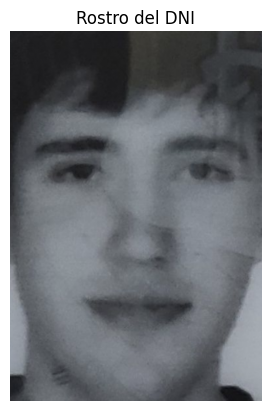

In [ ]:
real_time_verification(dni_path='dni_hugo_anverso.png')

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide (no presente en ambos)
Edad según el DNI: 20
Edad estimada por el modelo: 29
Edad coherente con el DNI
Escaneando...


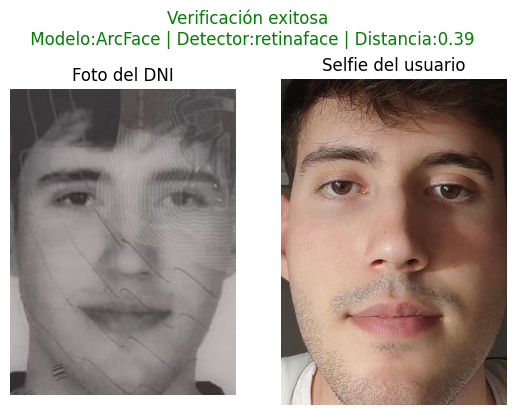

In [44]:
img1 = '.\DNI_especimen\hugo_anverso.jpeg'
img2 = '.\DNI_especimen\hugo_reverso.jpeg'
img3 = '.\caras\hugo.jpeg'
pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI MODERNO
El dni coincide
El num_sop no coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide
Edad según el DNI: 61
Edad estimada por el modelo: 42
POSIBLE INCONSISTENCIA DE EDAD
Escaneando...


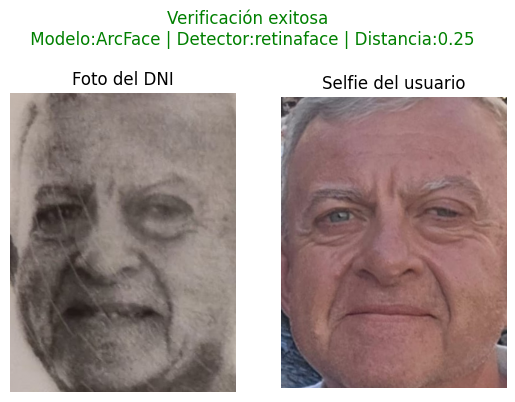

In [45]:
img1 = '.\DNI_especimen\ma_anverso.jpeg'
img2 = '.\DNI_especimen\ma_reverso.jpeg'
img3 = '.\caras\ma.jpeg'
pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide (no presente en ambos)
Edad según el DNI: 20
Edad estimada por el modelo: 32
POSIBLE INCONSISTENCIA DE EDAD
Escaneando...


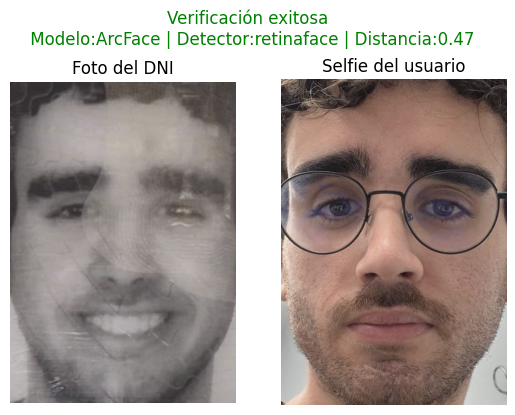

In [46]:
img1 = '.\DNI_especimen\carlos_anverso.jpeg'
img2 = '.\DNI_especimen\carlos_reverso.jpeg'
img3 = '.\caras\carlos.jpeg'

pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide (no presente en ambos)
Edad según el DNI: 20
Edad estimada por el modelo: 28
Edad coherente con el DNI
Escaneando...


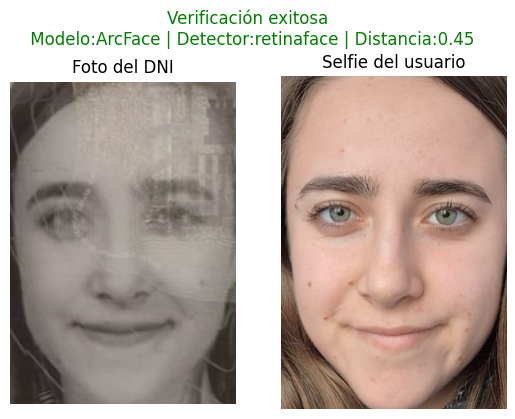

In [47]:
img1 = '.\DNI_especimen\p_anverso.jpeg'
img2 = '.\DNI_especimen\p_reverso.jpeg'
img3 = '.\caras\p.jpeg'

pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre: no se pudo comparar (solo presente en uno)
Edad según el DNI: 21
Edad estimada por el modelo: 25
Edad coherente con el DNI
Escaneando...


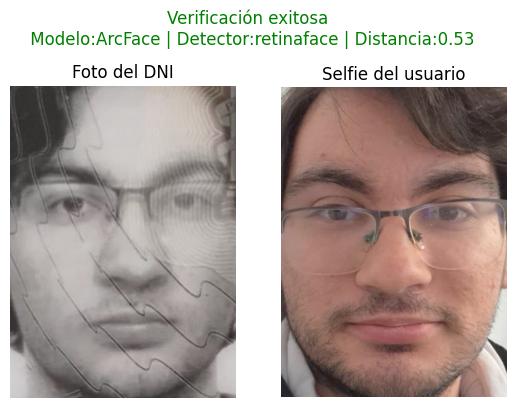

In [49]:
img1 = '.\DNI_especimen\gabriel_anverso.jpeg'
img2 = '.\DNI_especimen\gabriel_reverso.jpeg'
img3 = '.\caras\gabriel.jpeg'

pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide
Edad según el DNI: 20
Edad estimada por el modelo: 26
Edad coherente con el DNI
Escaneando...


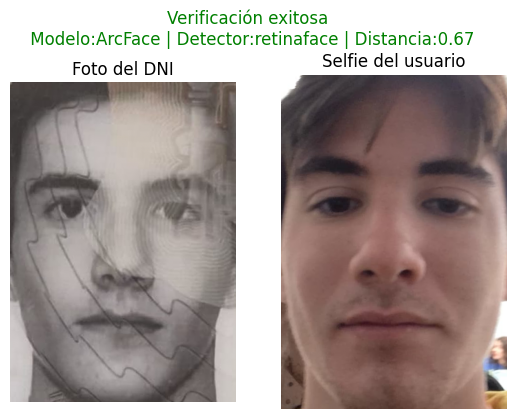

In [50]:
img1 = '.\DNI_especimen\jf_anverso.jpeg'
img2 = '.\DNI_especimen\jf_reverso.jpeg'
img3 = '.\caras\jf.jpeg'

pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

DNI ANTIGUO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide
Edad según el DNI: 57
Edad estimada por el modelo: 37
POSIBLE INCONSISTENCIA DE EDAD
Escaneando...


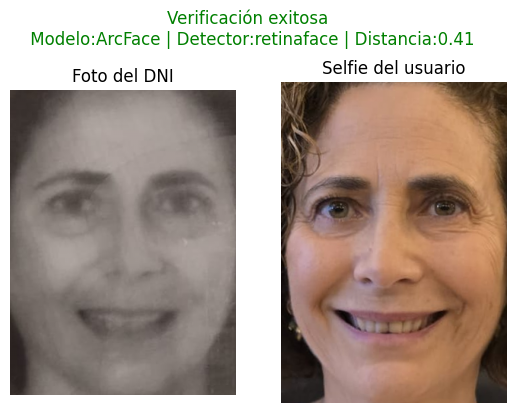

In [51]:
img1 = '.\DNI_especimen\mr_anverso.jpeg'
img2 = '.\DNI_especimen\mr_reverso.jpeg'
img3 = '.\caras\mr.jpeg'

pipeline(dni_anverso=img1, dni_reverso=img2, selfie=img3, verificar_edad=True)

### Prueba verificación de edad 

DNI MODERNO
El dni coincide
El num_sop coincide
La fecha de nacimiento coincide
La fecha de validez coincide
El primer apellido coincide
El segundo apellido coincide
El primer nombre coincide
El segundo nombre coincide (no presente en ambos)
Edad según el DNI: 20
Edad estimada por el modelo: 39
POSIBLE INCONSISTENCIA DE EDAD
Escaneando...


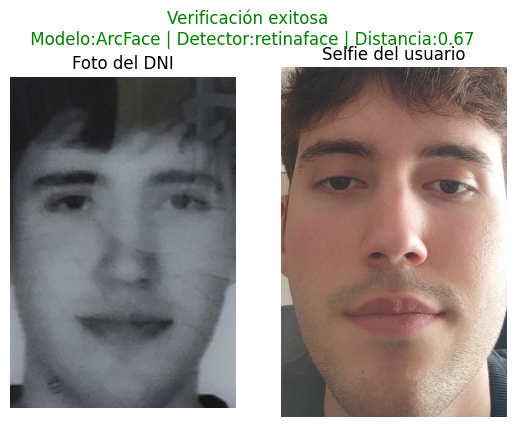

In [ ]:
#en este caso el modelo duda bastante
pipeline(dni_anverso='dni_hugo_anverso.png', dni_reverso= 'dni_hugo_reverso.png', selfie='hugo.jpg', verificar_edad=True, live=False)


Escaneando...


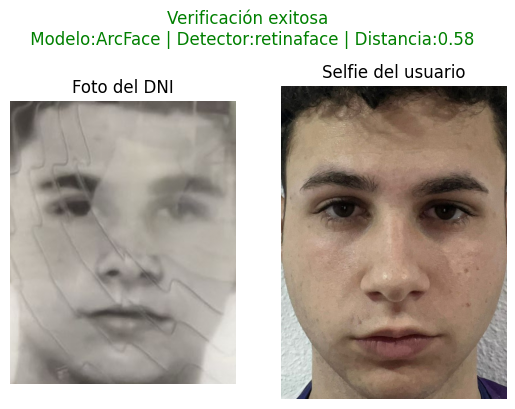

In [ ]:
one_shot_verification(dni_path='dni_alberto.jpg', selfie_path='alberto.jpg')

Escaneando...


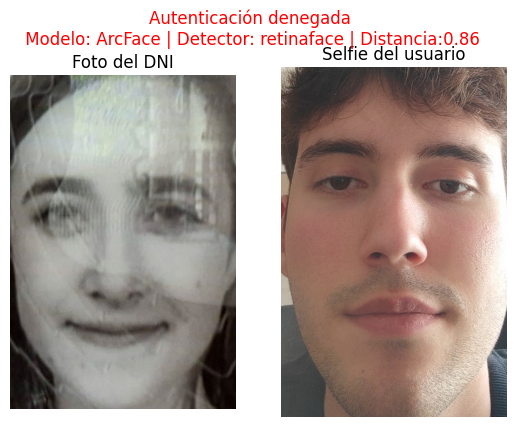

In [ ]:
one_shot_verification(dni_path='dni_patri.png', selfie_path='hugo.jpg')

Escaneando...


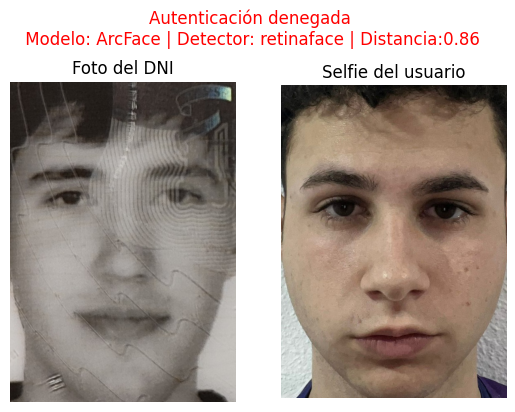

In [ ]:
one_shot_verification(dni_path='dni_anverso_nuevo.jpg', selfie_path='alberto.jpg')

Escaneando...


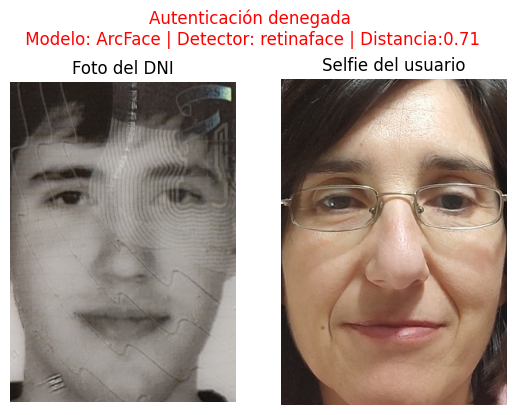

In [ ]:
one_shot_verification(dni_path='dni_anverso_nuevo.jpg', selfie_path='gema_selfie.jpg')

## El detector de opencv no detecta bien el rostro del DNI

Escaneando...


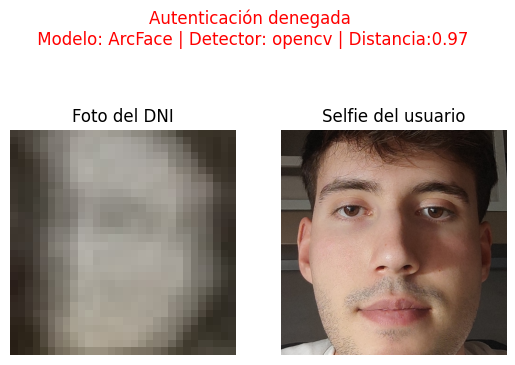

In [ ]:
one_shot_verification(dni_path='dni_anverso_nuevo.jpg', selfie_path='hugo2.jpg', detector_backend='opencv')